In [39]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
plt.rcParams.update({'font.size': 15, 'font.family': 'serif', 'mathtext.fontset' : 'cm'})

seeds = [0, 1, 2, 3, 4]
noise_levels = [0.0, 0.5, 1.0, 1.5, 2.0]
ks = [8, 16, 32]
methods = ['trivial', 'lpca', 'wlpca', 'lego']
methods_plotting = ['None', 'LPCA', 'WLPCA', 'LEGO']
markers = ['o', 's', '^', 'D']

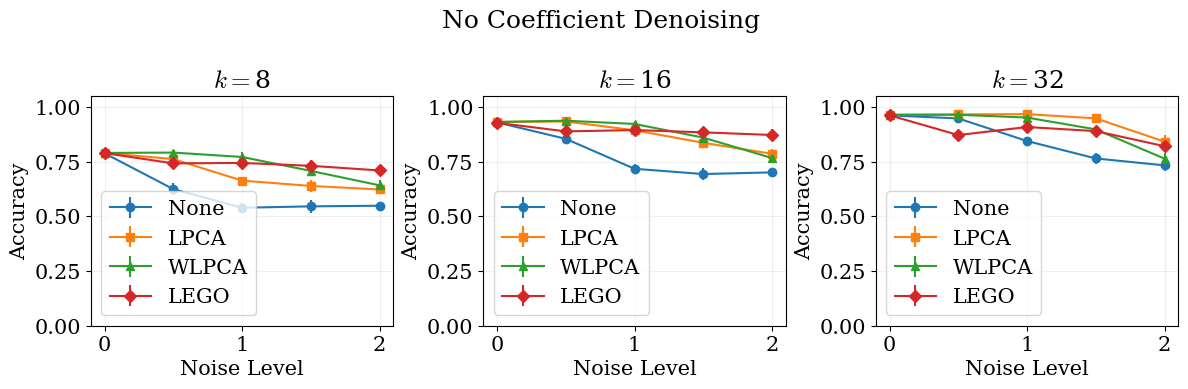

In [40]:
accuracy_by_noise = {(method, k): np.zeros((len(seeds), len(noise_levels))) for method, k in itertools.product(methods, ks)}

for seed in seeds:
    for noise in noise_levels:
        for k in ks:
            results = np.load(f'results/swiss_rolls_results_seed={seed}_noise={noise}_k={k}_smoothing=False.npz')
            for method in methods:
                accuracy_by_noise[(method, k)][seeds.index(seed), noise_levels.index(noise)] = results[f'{method}_correct']

fig, ax = plt.subplots(1,len(ks), figsize=(12,4))
fig.suptitle('No Coefficient Denoising')
for i, k in enumerate(ks):
    ax[i].set_ylim(0,1.05)
    ax[i].set_title(rf'$k=${k}')
    ax[i].grid(alpha=0.2)
    ax[i].set_xlabel('Noise Level')
    ax[i].set_ylabel('Accuracy')
    for j, method in enumerate(methods):
        # ax[i].plot(noise_levels, accuracy_by_noise[(method,k)].mean(axis=0), label=method)
        ax[i].errorbar(noise_levels, accuracy_by_noise[(method,k)].mean(axis=0),
                       yerr=accuracy_by_noise[(method,k)].std(axis=0),
                       marker=markers[j],
                       label=methods_plotting[j])
    ax[i].legend()
fig.tight_layout()
fig.savefig('../images/swiss_roll_accuracy_naive.pdf')

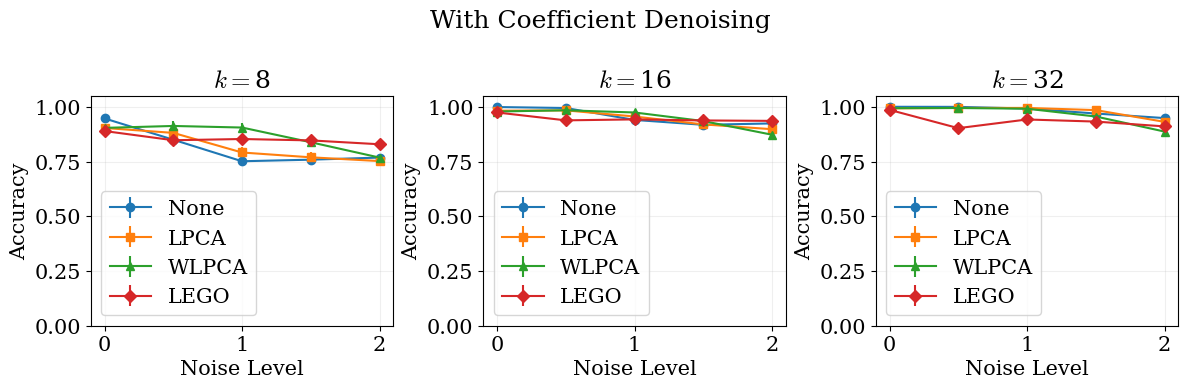

In [41]:
accuracy_by_noise = {(method, k): np.zeros((len(seeds), len(noise_levels))) for method, k in itertools.product(methods, ks)}

for seed in seeds:
    for noise in noise_levels:
        for k in ks:
            results = np.load(f'results/swiss_rolls_results_seed={seed}_noise={noise}_k={k}_smoothing=True.npz')
            for method in methods:
                accuracy_by_noise[(method, k)][seeds.index(seed), noise_levels.index(noise)] = results[f'{method}_correct']

fig, ax = plt.subplots(1,len(ks), figsize=(12,4))
fig.suptitle('With Coefficient Denoising')
for i, k in enumerate(ks):
    ax[i].set_ylim(0,1.05)
    ax[i].set_title(rf'$k=${k}')
    ax[i].grid(alpha=0.2)
    ax[i].set_xlabel('Noise Level')
    ax[i].set_ylabel('Accuracy')
    for j, method in enumerate(methods):
        # ax[i].plot(noise_levels, accuracy_by_noise[(method,k)].mean(axis=0), label=method)
        ax[i].errorbar(noise_levels, accuracy_by_noise[(method,k)].mean(axis=0),
                       yerr=accuracy_by_noise[(method,k)].std(axis=0),
                       marker=markers[j],
                       label=methods_plotting[j])
    ax[i].legend()
fig.tight_layout()
fig.savefig('../images/swiss_roll_accuracy_smoothed.pdf')

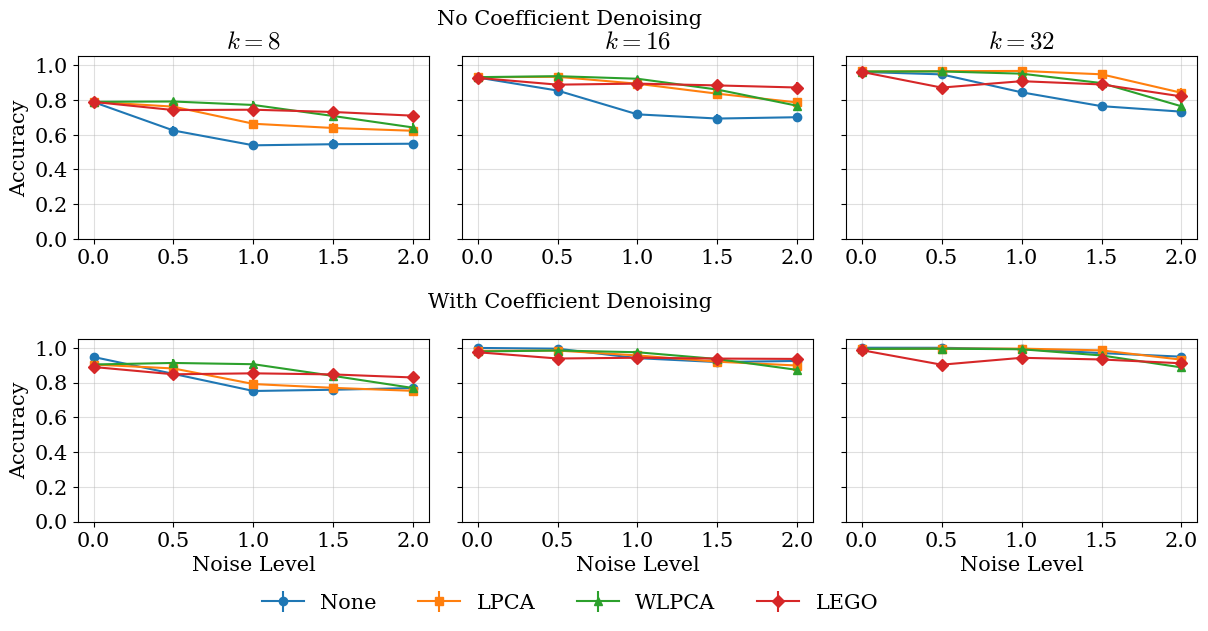

In [57]:
def load_accuracy_by_noise(smoothing):
    data = {(m, k): np.zeros((len(seeds), len(noise_levels))) for m, k in itertools.product(methods, ks)}
    for seed in seeds:
        for noise in noise_levels:
            for k in ks:
                results = np.load(
                    f"results/swiss_rolls_results_seed={seed}_noise={noise}_k={k}_smoothing={smoothing}.npz"
                )
                for m in methods:
                    data[(m, k)][seeds.index(seed), noise_levels.index(noise)] = results[f"{m}_correct"]
    return data

row_titles = ['No Coefficient Denoising', 'With Coefficient Denoising']
accuracy_no_smooth = load_accuracy_by_noise(False)
accuracy_smooth = load_accuracy_by_noise(True)


fig = plt.figure(figsize=(13, 5))
subfigs = fig.subfigures(2, 1, hspace=0.3)
ax_rows = []
for r, subfig in enumerate(subfigs):
    subfig.suptitle(row_titles[r], fontsize=15, y=1.1)
    axs = subfig.subplots(1, len(ks), sharex=True, sharey=True)
    ax_rows.append(axs)
ax = np.array(ax_rows)

all_data = [accuracy_no_smooth, accuracy_smooth]
for r, data in enumerate(all_data):
    for c, k in enumerate(ks):
        ax[r, c].set_ylim(0, 1.05)
        ax[r, c].set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
        ax[r, c].grid(alpha=0.4)
        if r == 0:
            ax[r, c].set_title(rf"$k={k}$")
        if c == 0:
            ax[r, c].set_ylabel("Accuracy")
        if r == 1:
            ax[r, c].set_xlabel("Noise Level")

        for j, m in enumerate(methods):
            ax[r, c].errorbar(
                noise_levels,
                data[(m, k)].mean(axis=0),
                yerr=data[(m, k)].std(axis=0),
                marker=markers[j],
                label=methods_plotting[j] if (r == 0 and c == 0) else None,
            )

handles, labels = ax[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=len(methods), frameon=False, bbox_to_anchor=(0.5, -0.2))
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig("../images/swiss_roll_accuracy.pdf", bbox_inches="tight")
plt.show()